<a href="https://colab.research.google.com/github/piush365/PromptOpt/blob/main/DollyEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q datasets pandas numpy matplotlib seaborn

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

In [ ]:
ds = load_dataset("databricks/databricks-dolly-15k")
print(ds)

df = ds["train"].to_pandas()
print(df.shape)
df.head()

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl: reconstructing file:   0%|          |  0.00B / 13.1MB            

databricks-dolly-15k.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'context', 'response', 'category'],
        num_rows: 15011
    })
})
(15011, 4)


,instruction,context,response,category
0,When did Virgin Australia start operating?,"Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the l...","Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.",closed_qa
1,Which is a species of fish? Tope or Rope,,Tope,classification
2,Why can camels survive for long without water?,,Camels use the fat in their humps to keep them filled with energy and hydration for long periods of time.,open_qa
3,"Alice's parents have three daughters: Amy, Jessy, and what’s the name of the third daughter?",,The name of the third daughter is Alice,open_qa
4,When was Tomoaki Komorida born?,"Komorida was born in Kumamoto Prefecture on July 10, 1981. After graduating from high school, he joined the J1 Leagu...","Tomoaki Komorida was born on July 10,1981.",closed_qa


In [ ]:
print("Columns:", df.columns.tolist())
print("\nNull counts:\n", df.isnull().sum())
for col in ["instruction", "context", "response"]:
    print(f"Empty '{col}': {(df[col].astype(str).str.strip() == '').sum()}")

Columns: ['instruction', 'context', 'response', 'category']

Null counts:
 instruction    0
context        0
response       0
category       0
dtype: int64
Empty 'instruction': 0
Empty 'context': 10544
Empty 'response': 0


In [ ]:
dup_instruction = df["instruction"].duplicated().sum()
dup_full_row = df.duplicated(subset=["instruction", "context", "response"]).sum()
print(f"Duplicate instructions: {dup_instruction}")
print(f"Fully duplicate rows: {dup_full_row}")

norm = df["instruction"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
print(f"Duplicate instructions after normalization: {norm.duplicated().sum()}")

Duplicate instructions: 232
Fully duplicate rows: 15
Duplicate instructions after normalization: 250


In [ ]:
df["has_context"] = df["context"].astype(str).str.strip().ne("")
print(df["has_context"].value_counts())
print(f"% with context: {df['has_context'].mean()*100:.2f}%")

has_context
False    10544
True      4467
Name: count, dtype: int64
% with context: 29.76%


category
open_qa                   3742
general_qa                2191
classification            2136
closed_qa                 1773
brainstorming             1766
information_extraction    1506
summarization             1188
creative_writing           709
Name: count, dtype: int64


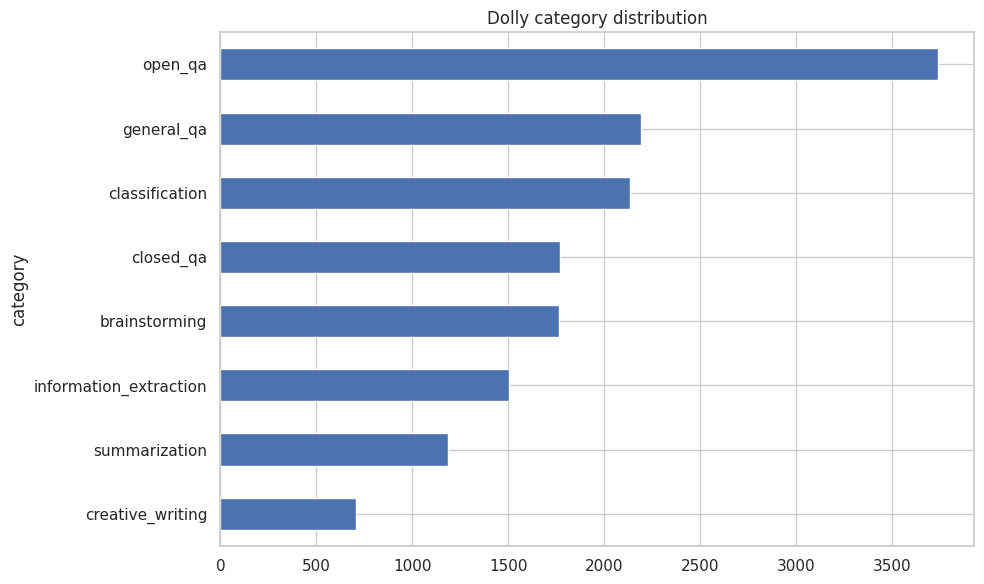

In [ ]:
cat_counts = df["category"].value_counts()
print(cat_counts)

fig, ax = plt.subplots(figsize=(10, 6))
cat_counts.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Dolly category distribution")
plt.tight_layout()
plt.savefig("dolly_category_distribution.png", dpi=150)
plt.show()

In [ ]:
def word_count(s):
    return len(str(s).split())

def char_count(s):
    return len(str(s))

for col in ["instruction", "context", "response"]:
    df[f"{col}_words"] = df[col].apply(word_count)
    df[f"{col}_chars"] = df[col].apply(char_count)

length_summary = df[[f"{c}_words" for c in ["instruction", "context", "response"]]].describe(
    percentiles=[.05, .25, .5, .75, .9, .95, .99]
)
print(length_summary)

       instruction_words  context_words  response_words
count       15011.000000   15011.000000    15011.000000
mean           12.378656      56.667510       60.115515
std            17.048248     153.330154       98.312539
min             1.000000       0.000000        1.000000
5%              4.000000       0.000000        2.000000
25%             7.000000       0.000000       13.000000
50%            10.000000       0.000000       31.000000
75%            14.000000      66.000000       73.000000
90%            21.000000     176.000000      137.000000
95%            27.000000     277.000000      202.000000
99%            47.000000     634.000000      433.900000
max           841.000000    3796.000000     4274.000000


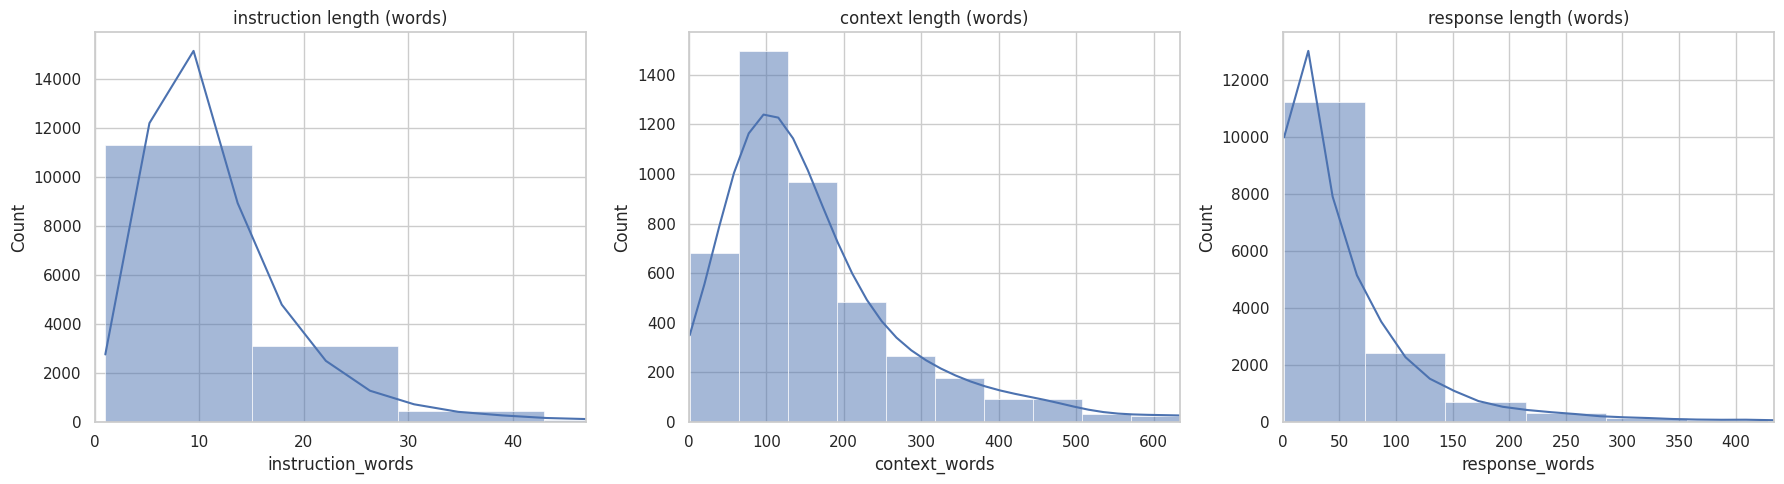

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["instruction", "context", "response"]):
    sub = df[df[f"{col}_words"] > 0][f"{col}_words"]
    sns.histplot(sub, bins=60, ax=ax, kde=True)
    ax.set_title(f"{col} length (words)")
    ax.set_xlim(0, df[f"{col}_words"].quantile(0.99))
plt.tight_layout()
plt.savefig("dolly_length_histograms.png", dpi=150)
plt.show()

                        count       mean  median        std  min  max
category                                                             
classification           2136  19.022472    17.0  14.797951    3  266
creative_writing          709  16.375176    13.0  12.479713    1  150
general_qa               2191  12.859881     8.0  36.005986    2  841
information_extraction   1506  12.853254    12.0   8.267720    3  187
closed_qa                1773  12.758601    11.0  15.424993    1  599
brainstorming            1766  11.616648    10.0   8.109850    2  115
summarization            1188   9.984848     9.0   7.665266    1  208
open_qa                  3742   8.295831     8.0   3.949072    1   41


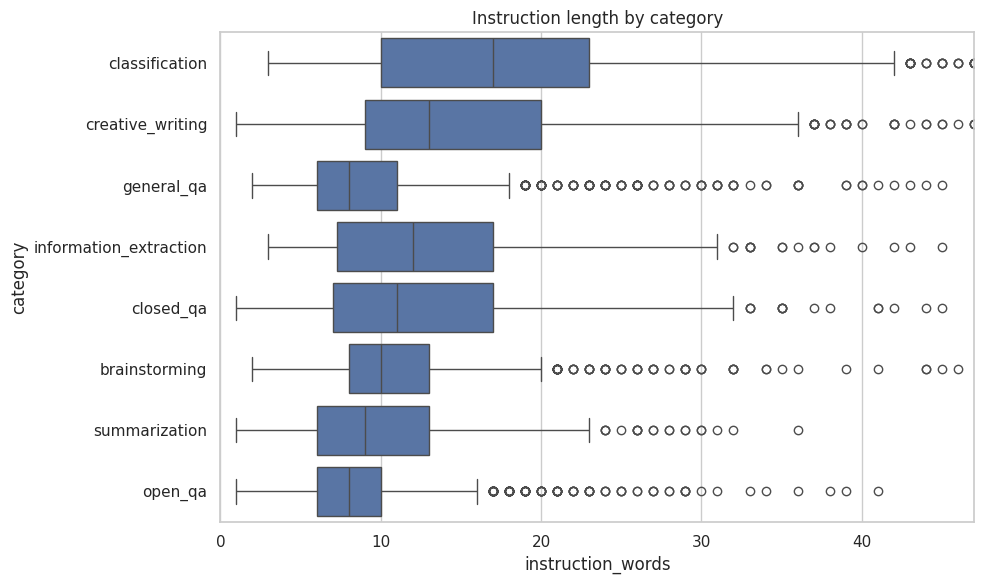

In [ ]:
cat_length = df.groupby("category")["instruction_words"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).sort_values("mean", ascending=False)
print(cat_length)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, y="category", x="instruction_words", ax=ax,
            order=cat_length.index)
ax.set_xlim(0, df["instruction_words"].quantile(0.99))
ax.set_title("Instruction length by category")
plt.tight_layout()
plt.savefig("dolly_instrlen_by_category.png", dpi=150)
plt.show()

                        count        mean  median         std  min   max
category                                                                
creative_writing          709  176.396333   118.0  189.842269    1  1727
general_qa               2191   98.899589    75.0   94.524679    1  1513
summarization            1188   80.284512    54.0  156.575505    2  4274
brainstorming            1766   58.591166    37.0   74.919095    1  1122
open_qa                  3742   49.600481    26.5   71.139460    1  1230
information_extraction   1506   48.978752    19.0  104.955537    1  1323
closed_qa                1773   30.668923    17.0   48.159516    1   629
classification           2136   22.493914    14.0   36.435384    1   562


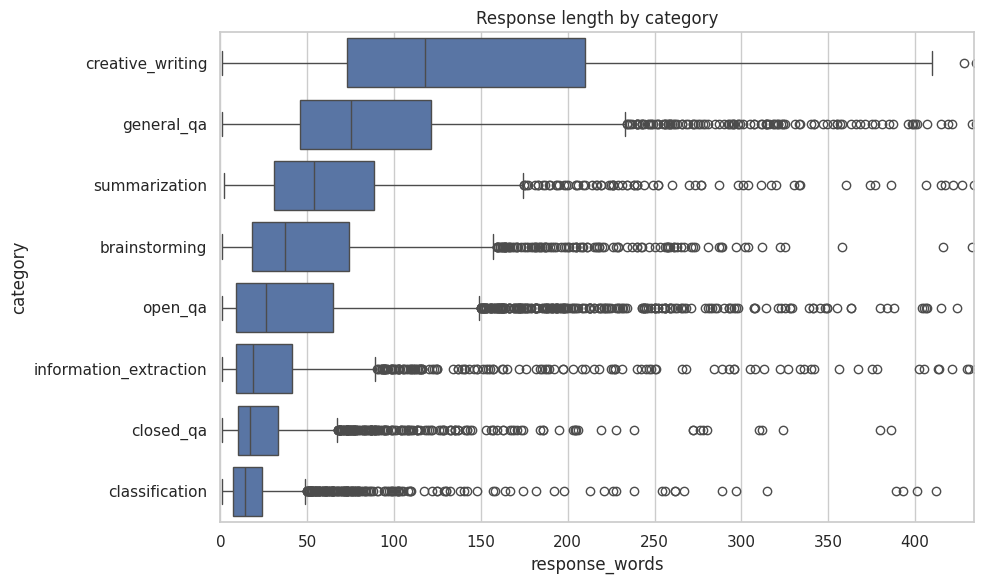

In [ ]:
cat_resp_length = df.groupby("category")["response_words"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).sort_values("mean", ascending=False)
print(cat_resp_length)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, y="category", x="response_words", ax=ax,
            order=cat_resp_length.index)
ax.set_xlim(0, df["response_words"].quantile(0.99))
ax.set_title("Response length by category")
plt.tight_layout()
plt.savefig("dolly_resplen_by_category.png", dpi=150)
plt.show()

category
closed_qa                 100.0
information_extraction    100.0
summarization             100.0
brainstorming               0.0
creative_writing            0.0
classification              0.0
general_qa                  0.0
open_qa                     0.0
Name: has_context, dtype: float64


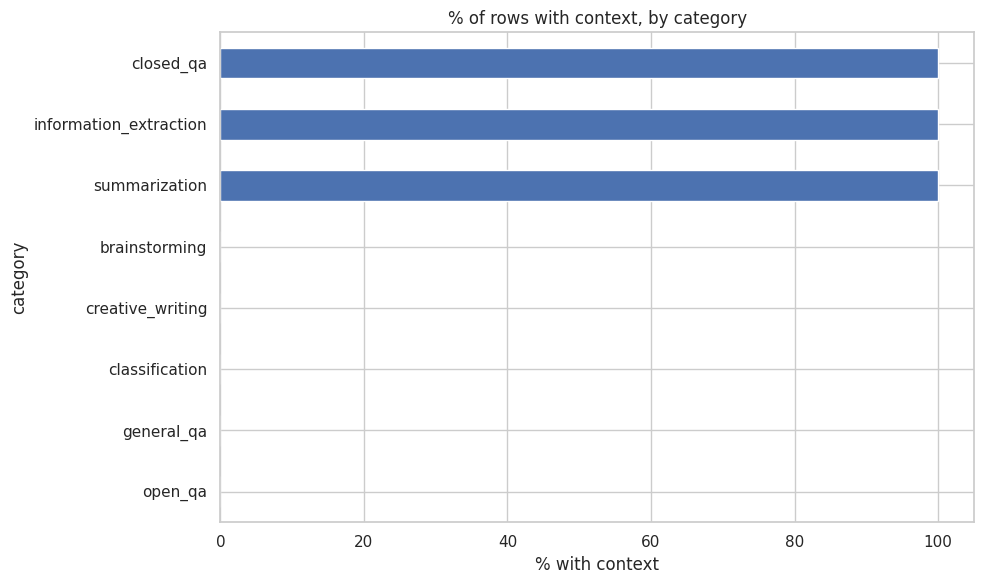

In [ ]:
context_by_cat = df.groupby("category")["has_context"].mean().sort_values(ascending=False) * 100
print(context_by_cat)

fig, ax = plt.subplots(figsize=(10, 6))
context_by_cat.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("% of rows with context, by category")
ax.set_xlabel("% with context")
plt.tight_layout()
plt.savefig("dolly_context_by_category.png", dpi=150)
plt.show()

In [ ]:
empty_responses = (df["response"].astype(str).str.strip() == "").sum()
very_short_responses = (df["response_words"] <= 2).sum()
print(f"Empty responses: {empty_responses}")
print(f"Responses with <=2 words: {very_short_responses}")
df[df["response_words"] <= 2][["category", "instruction", "response"]].head(10)

Empty responses: 0
Responses with <=2 words: 780


,category,instruction,response
1,classification,Which is a species of fish? Tope or Rope,Tope
22,open_qa,Which Dutch artist painted “Girl with a Pearl Earring”?,Vermeer
31,open_qa,Who played Billy the Kid in The Left Handed Gun,Paul Newman
37,open_qa,Who saved Andromeda from the sea monster,Perseus
51,open_qa,"In the series A Song of Ice and Fire, who is the founder of House Karstark?",Karlon Stark
53,open_qa,What film won the 1943 Oscar as best film,Casablanca
110,open_qa,In golf what do the Americans call an albatross,Double Eagle
116,open_qa,"What is the name of the Winslow's nerdy next-door neighbor on the TV show ""Family Matters""?",Steve Urkel
129,classification,Which is a species of fish? Sea dragon or Red bearded,Sea dragon
174,open_qa,Tomb of Sand was translated from Hindi to English by,Daisy Rockwell


In [ ]:
FORMAT_PATTERNS = {
    "list": r"\blist\b|\benumerate\b",
    "table": r"\btable\b|\bmarkdown table\b",
    "json": r"\bjson\b",
    "bullets": r"\bbullet(s)?\b|\bbulleted\b",
    "paragraph": r"\bparagraph\b|\bessay\b",
    "steps": r"\bstep(s)?\b|\bstep[- ]by[- ]step\b",
    "numbered": r"\bnumbered\b|\b\d+\.\s",
}

def detect_formats(text):
    text = str(text).lower()
    return [name for name, pat in FORMAT_PATTERNS.items() if re.search(pat, text)]

df["requested_formats"] = df["instruction"].apply(detect_formats)
df["has_format_request"] = df["requested_formats"].apply(len).gt(0)
print(f"% instructions with explicit format request: {df['has_format_request'].mean()*100:.2f}%")

fmt_by_cat = df.groupby("category")["has_format_request"].mean().sort_values(ascending=False) * 100
print("\nFormat-request rate by category:\n", fmt_by_cat)

% instructions with explicit format request: 11.36%

Format-request rate by category:
 category
brainstorming             27.972820
information_extraction    25.166003
closed_qa                 20.924986
summarization             16.498316
creative_writing           8.039492
classification             4.822097
general_qa                 1.916933
open_qa                    1.683592
Name: has_format_request, dtype: float64


In [ ]:
corr = df["instruction_words"].corr(df["response_words"])
print(f"Pearson correlation (instruction_words vs response_words): {corr:.3f}")

Pearson correlation (instruction_words vs response_words): 0.005


In [ ]:
EMAIL_RE = r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}"
PHONE_RE = r"\b\d{3}[-.\s]??\d{3}[-.\s]??\d{4}\b"

def contains_pii(text):
    text = str(text)
    return bool(re.search(EMAIL_RE, text) or re.search(PHONE_RE, text))

df["has_pii"] = (df["instruction"] + " " + df["context"] + " " + df["response"]).apply(contains_pii)
print(f"Rows with likely email/phone PII: {df['has_pii'].sum()}")

Rows with likely email/phone PII: 9


In [ ]:
summary = {
    "total_rows": len(df),
    "num_categories": df["category"].nunique(),
    "fully_duplicate_rows": int(dup_full_row),
    "duplicate_instructions": int(dup_instruction),
    "pct_with_context": round(df["has_context"].mean() * 100, 2),
    "pct_empty_response": round(empty_responses / len(df) * 100, 4),
    "pct_format_request": round(df["has_format_request"].mean() * 100, 2),
    "median_instruction_words": int(df["instruction_words"].median()),
    "median_response_words": int(df["response_words"].median()),
    "max_response_words": int(df["response_words"].max()),
    "instruction_response_word_corr": round(corr, 3),
    "rows_with_pii_hits": int(df["has_pii"].sum()),
}
summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
print(summary_df)
summary_df.to_csv("dolly_eda_summary.csv")
cat_length.to_csv("dolly_instrlen_by_category.csv")
cat_resp_length.to_csv("dolly_resplen_by_category.csv")

                                    value
total_rows                      15011.000
num_categories                      8.000
fully_duplicate_rows               15.000
duplicate_instructions            232.000
pct_with_context                   29.760
pct_empty_response                  0.000
pct_format_request                 11.360
median_instruction_words           10.000
median_response_words              31.000
max_response_words               4274.000
instruction_response_word_corr      0.005
rows_with_pii_hits                  9.000


In [ ]:
df.to_parquet("dolly_15k_enriched.parquet")
print("Saved: dolly_eda_summary.csv, category CSVs, dolly_15k_enriched.parquet, and PNG charts")

Saved: dolly_eda_summary.csv, category CSVs, dolly_15k_enriched.parquet, and PNG charts


In [ ]:
alpaca_df = pd.read_parquet("alpaca_cleaned_enriched.parquet")
dolly_df = df

comparison = pd.DataFrame({
    "alpaca": [
        len(alpaca_df),
        alpaca_df["instruction_words"].median(),
        alpaca_df["output_words"].median(),
        alpaca_df["has_format_request"].mean() * 100,
        alpaca_df["has_input"].mean() * 100,
    ],
    "dolly": [
        len(dolly_df),
        dolly_df["instruction_words"].median(),
        dolly_df["response_words"].median(),
        dolly_df["has_format_request"].mean() * 100,
        dolly_df["has_context"].mean() * 100,
    ],
}, index=["rows", "median_instr_words", "median_output_words",
          "pct_format_request", "pct_has_context_or_input"])
print(comparison)

                                alpaca         dolly
rows                      51760.000000  15011.000000
median_instr_words           10.000000     10.000000
median_output_words          80.000000     31.000000
pct_format_request           11.163060     11.358337
pct_has_context_or_input     37.011206     29.758177
